# Funções — Conceito, Notação e Domínio

**Módulo:** 01 – Conjuntos e Funções

**Pré-requisitos:** [`0104a_relacoes.ipynb`](0104a_relacoes.ipynb) (relação entre conjuntos, pares ordenados, domínio/contradomínio/imagem), além do Python básico de [00_fundamentos_e_python/](../00_fundamentos_e_python/) (funções em Python como analogia)

**Objetivos de aprendizagem:**
- Reconhecer se uma relação entre dois conjuntos é ou não é uma função.
- Determinar domínio, contradomínio e imagem de uma função, inclusive quando a lei de formação impõe restrições.
- Resolver inequações simples para encontrar o domínio de validade de uma expressão.
- Verificar se duas funções são iguais e identificar os zeros de uma função a partir do gráfico ou da lei de formação.

**Tempo estimado:** 70 a 90 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/01_conjuntos_e_funcoes/0105a_funcoes.ipynb)

## Quanto custa a corrida?

Um aplicativo de transporte cobra uma **bandeirada fixa de R$ 4,00**, mais **R$ 2,50 por km** rodado. Para algumas corridas do dia, a tela do motorista mostrou:

| Distância (km) | Preço (R$) |
|---|---|
| 1 | 6,50 |
| 2 | 9,00 |
| 3 | 11,50 |
| 5 | 16,50 |
| 8 | 24,00 |

Olhando essa tabela: existe alguma distância que aparece duas vezes, com preços diferentes? Parece que não — **para cada distância rodada existe sempre um único preço**. Essa ideia de "para cada entrada, uma única saída" é exatamente o que vamos formalizar neste notebook: o conceito de **função**.

## A função como "máquina"

- Uma **função** pode ser vista como uma máquina: ela recebe uma **entrada**, aplica sempre a **mesma transformação**, e devolve uma **saída**. A mesma entrada, colocada na máquina duas vezes, sempre produz a mesma saída.
- Na abertura do notebook, a "máquina" é a regra de cobrança do aplicativo: entra a distância, sai o preço, sempre pela mesma conta (bandeirada + valor por km).
- Isso conecta diretamente com o que vimos em [`0104a_relacoes.ipynb`](0104a_relacoes.ipynb): uma função é um tipo particular de **relação** entre dois conjuntos — só que com regras extras, que vamos ver no próximo bloco.

In [2]:
def maquina(entrada: float) -> float:
    '''Calcula o preco da corrida: bandeirada fixa + valor por km rodado.'''
    bandeirada = 4.0
    preco_por_km = 2.5
    return bandeirada + preco_por_km * entrada


distancias = [1, 2, 3, 5, 8]
precos = [maquina(distancia) for distancia in distancias]

for distancia, preco in zip(distancias, precos):
    print(f"distância = {distancia} km  ->  preço = R$ {preco:.2f}")

distância = 1 km  ->  preço = R$ 6.50
distância = 2 km  ->  preço = R$ 9.00
distância = 3 km  ->  preço = R$ 11.50
distância = 5 km  ->  preço = R$ 16.50
distância = 8 km  ->  preço = R$ 24.00


**Perguntas de checagem:**
1. Na tabela da abertura, existe alguma distância que gera dois preços diferentes?
2. O que muda entre uma "relação qualquer" (vista em [`0104a_relacoes.ipynb`](0104a_relacoes.ipynb)) e uma "função"?

## Definição formal de função

- 📌 **Definição formal:** dados dois conjuntos A e B **não vazios**, uma **função** f de A em B é uma relação que associa **a cada elemento de A** um **único** elemento de B. Duas condições precisam valer ao mesmo tempo:
    - **Existência:** todo elemento de A precisa ter algum correspondente em B (nenhum elemento de A pode ficar "sem seta").
    - **Unicidade:** cada elemento de A pode ter **no máximo um** correspondente em B (nenhum elemento de A pode ter "duas setas").
- ⚠️ **Erro comum:** achar que toda relação entre dois conjuntos é uma função. Como vimos em [`0104a_relacoes.ipynb`](0104a_relacoes.ipynb), uma relação é **qualquer** subconjunto de A × B — função é uma relação que, além disso, satisfaz existência e unicidade.
- Repare que sobrar elemento em B **sem receber seta** não é problema — isso só significa que aquele elemento não faz parte da imagem (mais sobre isso no Bloco 4).

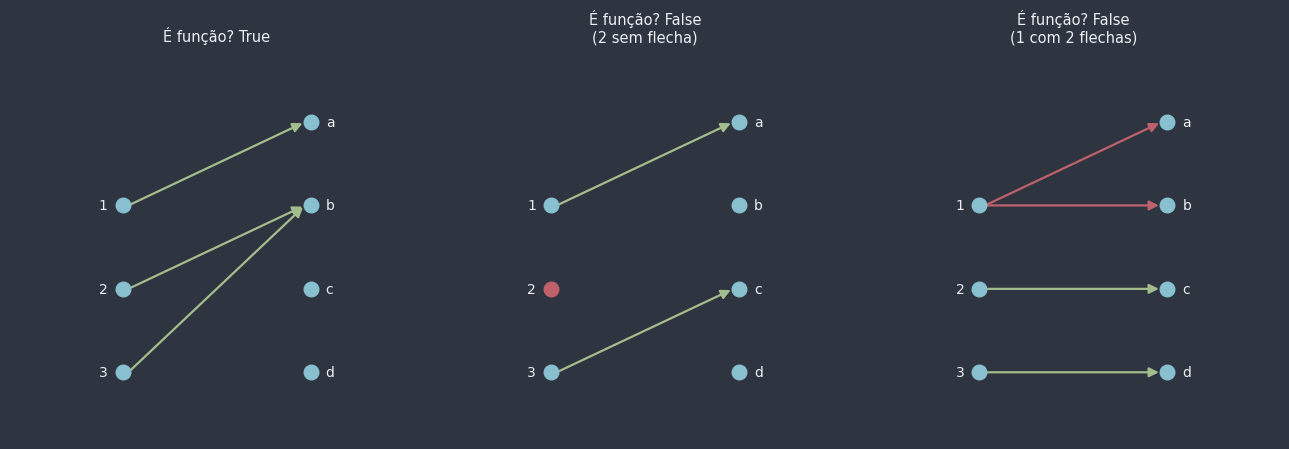

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"


def eh_funcao(conjunto_a: set, flechas: list[tuple]) -> bool:
    '''Verifica se as flechas (pares (a, b)) definem uma funcao de conjunto_a em B.

    Args:
        conjunto_a: conjunto de partida.
        flechas: lista de pares (a, b) representando as flechas desenhadas.

    Returns:
        True se todo elemento de conjunto_a aparece em exatamente uma flecha.
    '''
    origens = [a for a, _ in flechas]
    existencia = all(a in origens for a in conjunto_a)
    unicidade = len(origens) == len(set(origens))
    return existencia and unicidade


def diagrama_sagital(
    lista_a: list,
    lista_b: list,
    flechas: list[tuple],
    cores_flechas: list[str] | None = None,
    nos_alerta: set | None = None,
    titulo: str = "",
    ax=None,
) -> None:
    '''Desenha um diagrama de flechas (sagital) entre duas colunas de nos, A e B.

    Args:
        lista_a: elementos do conjunto de partida, exibidos na coluna esquerda.
        lista_b: elementos do conjunto de chegada, exibidos na coluna direita.
        flechas: lista de pares (a, b) a ligar com uma flecha.
        cores_flechas: cor de cada flecha, na mesma ordem de `flechas`.
        nos_alerta: elementos de lista_a a destacar em vermelho (ex: sem flecha).
        titulo: titulo exibido acima do diagrama.
        ax: eixo do matplotlib onde desenhar; se None, cria uma figura nova.
    '''
    criou_figura = ax is None
    if criou_figura:
        fig, ax = plt.subplots(figsize=(4.3, 4.3))
        fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    nos_alerta = nos_alerta or set()
    cores_flechas = cores_flechas or [COR_DESTAQUE] * len(flechas)

    y_a = {a: i for i, a in enumerate(reversed(lista_a))}
    y_b = {b: i for i, b in enumerate(reversed(lista_b))}
    x_a, x_b = 0.0, 1.0

    for a, y in y_a.items():
        cor_no = COR_ALERTA if a in nos_alerta else COR_PONTO
        ax.scatter([x_a], [y], s=110, color=cor_no, zorder=3)
        ax.text(
            x_a - 0.08, y, str(a), color=NORD_TEXTO,
            fontsize=10, ha="right", va="center",
        )
    for b, y in y_b.items():
        ax.scatter([x_b], [y], s=110, color=COR_PONTO, zorder=3)
        ax.text(
            x_b + 0.08, y, str(b), color=NORD_TEXTO,
            fontsize=10, ha="left", va="center",
        )

    for (a, b), cor in zip(flechas, cores_flechas):
        if a in y_a and b in y_b:
            seta = FancyArrowPatch(
                (x_a + 0.03, y_a[a]), (x_b - 0.03, y_b[b]),
                arrowstyle="-|>", mutation_scale=14,
                color=cor, linewidth=1.6, zorder=2,
            )
            ax.add_patch(seta)

    ax.set_xlim(-0.6, 1.6)
    margem = 0.8
    altura = max(len(lista_a), len(lista_b)) - 1 + margem
    ax.set_ylim(-margem, altura)
    ax.axis("off")
    if titulo:
        ax.set_title(titulo, color=NORD_TEXTO, fontsize=10.5, pad=10)

    if criou_figura:
        plt.show()


lista_a = [1, 2, 3]
lista_b = ["a", "b", "c", "d"]

caso_funcao = [(1, "a"), (2, "b"), (3, "b")]
caso_falta_seta = [(1, "a"), (3, "c")]
caso_duas_setas = [(1, "a"), (1, "b"), (2, "c"), (3, "d")]

fig, eixos = plt.subplots(1, 3, figsize=(13, 4.6))
fig.patch.set_facecolor(NORD_FUNDO)

diagrama_sagital(
    lista_a, lista_b, caso_funcao,
    titulo=f"É função? {eh_funcao(set(lista_a), caso_funcao)}", ax=eixos[0],
)
diagrama_sagital(
    lista_a, lista_b, caso_falta_seta, nos_alerta={2},
    titulo=f"É função? {eh_funcao(set(lista_a), caso_falta_seta)}\n(2 sem flecha)",
    ax=eixos[1],
)
diagrama_sagital(
    lista_a, lista_b, caso_duas_setas,
    cores_flechas=[COR_ALERTA, COR_ALERTA, COR_DESTAQUE, COR_DESTAQUE],
    titulo=f"É função? {eh_funcao(set(lista_a), caso_duas_setas)}\n(1 com 2 flechas)",
    ax=eixos[2],
)
plt.tight_layout()
plt.show()

**Perguntas de checagem:**
1. Por que um elemento de A com duas flechas saindo dele impede que a relação seja função?
2. Pode sobrar elemento em B sem receber flecha? E em A?

## Notação das funções

- Uma função de A em B se escreve **f: A → B** ("f de A em B"). A regra que calcula a saída a partir da entrada é a **lei de formação** (a fórmula).
- **f** é o nome da função (a "máquina" inteira); **f(x)** é o **valor** que a função devolve quando a entrada é x (o resultado de uma passada específica pela máquina). São coisas diferentes: f é a máquina, f(x) é uma saída dela.
- A leitura "f(2) = 9" significa "a função f, aplicada à entrada 2, devolve a saída 9".

In [4]:
def f(x: float) -> float:
    '''f: A -> B, f(x) = 4 + 2.5x (a mesma "maquina" do gancho, com notacao formal).'''
    return 4 + 2.5 * x


for x in [0, 1, 2.5, 5]:
    print(f"f({x:g}) = {f(x):g}")

f(0) = 4
f(1) = 6.5
f(2.5) = 10.25
f(5) = 16.5


**Pergunta de checagem:**
1. Qual a diferença entre escrever "f" e escrever "f(3)"?

## Domínio, contradomínio e imagem

- 📌 **Definições**, para uma função f: A → B:
    - **Domínio:** o conjunto de partida, A — todas as entradas válidas para f.
    - **Contradomínio:** o conjunto de chegada, B — o conjunto onde as saídas *poderiam* estar.
    - **Imagem:** o subconjunto do contradomínio **efetivamente atingido** por alguma saída de f. Ou seja, Im(f) = {f(x) | x ∈ domínio}.
- A imagem é **sempre** um subconjunto do contradomínio (Im(f) ⊆ B), mas não precisa ser igual a ele — pode sobrar elemento em B que nenhuma entrada alcança.

Use o slider abaixo para escolher o domínio [a, b] da função g(x) = x² (contradomínio declarado como R) e veja a imagem correspondente, em três representações: fórmula, gráfico e tabela de valores.

In [5]:
import ipywidgets as widgets
import numpy as np
import pandas as pd
from IPython.display import display


def g(x):
    return x**2


def explorar_dominio(intervalo: tuple[float, float]) -> None:
    a, b = intervalo
    xs = np.linspace(a, b, 400)
    ys = g(xs)
    imagem_min, imagem_max = ys.min(), ys.max()

    xs_completo = np.linspace(-5, 5, 400)
    fig, ax = plt.subplots(figsize=(6, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.plot(xs_completo, g(xs_completo), color=NORD_LINHA, linewidth=1.3, zorder=1)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.6, zorder=2, label="domínio [a, b]")
    ax.axhspan(imagem_min, imagem_max, color=COR_PONTO, alpha=0.15, zorder=0)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8, zorder=1)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8, zorder=1)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.set_title(
        f"Domínio = [{a:g}, {b:g}]   Imagem = [{imagem_min:g}, {imagem_max:g}]",
        color=NORD_TEXTO, fontsize=10.5,
    )
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)
    plt.show()

    print("Fórmula: g(x) = x², contradomínio declarado = R")
    print(f"Domínio = [{a:g}, {b:g}]")
    print(f"Imagem  = [{imagem_min:g}, {imagem_max:g}]")

    indices_tabela = np.linspace(0, len(xs) - 1, 6).round().astype(int)
    tabela = pd.DataFrame({"x": xs[indices_tabela].round(2), "g(x)": ys[indices_tabela].round(2)})
    display(tabela)


widgets.interact(
    explorar_dominio,
    intervalo=widgets.FloatRangeSlider(
        value=[-2, 3], min=-5, max=5, step=0.5, description="[a, b]:",
    ),
)

interactive(children=(FloatRangeSlider(value=(-2.0, 3.0), description='[a, b]:', max=5.0, min=-5.0, step=0.5),…

<function __main__.explorar_dominio(intervalo: tuple) -> None>

**Pergunta de checagem:**
1. A imagem pode ser igual ao contradomínio? Sempre?

## Domínio de validade de uma expressão

- Quando o domínio não é dado explicitamente, ele é determinado pelas **restrições da própria lei de formação**:
    - **Denominador diferente de zero** — uma fração só existe se o denominador não for zero.
    - **Radicando não negativo** (para radical de índice par) — não existe raiz quadrada real de número negativo.
- Para encontrar essas restrições, usamos **inequações**: a mesma ideia de equação, mas com `<`, `>`, `≤` ou `≥` no lugar de `=`.
- 📌 **Definição formal:**
    - **Inequação:** sentença matemática que compara duas expressões usando `<`, `>`, `≤` ou `≥`.
    - **Solução:** valor que, substituído na inequação, torna a comparação verdadeira. **Conjunto-solução:** o conjunto de todas as soluções.
    - **Inequações equivalentes:** têm o mesmo conjunto-solução. Uma inequação continua equivalente se somarmos/subtrairmos o mesmo valor dos dois lados, ou se multiplicarmos/dividirmos os dois lados por um número **positivo**.
- ⚠️ **Erro comum:** esquecer de **inverter o sinal da desigualdade** ao multiplicar ou dividir os dois lados por um número **negativo**. Ex: -2x > 4 ⟺ x < -2 (o `>` virou `<`).

**Exemplo 1 — f(x) = 1/(x - 2):**
Denominador ≠ 0 ⟹ x - 2 ≠ 0 ⟹ **x ≠ 2**. Domínio: R - {2}.

**Exemplo 2 — f(x) = √(x + 3):**
Radicando ≥ 0 ⟹ x + 3 ≥ 0 ⟹ **x ≥ -3**. Domínio: [-3, +∞).

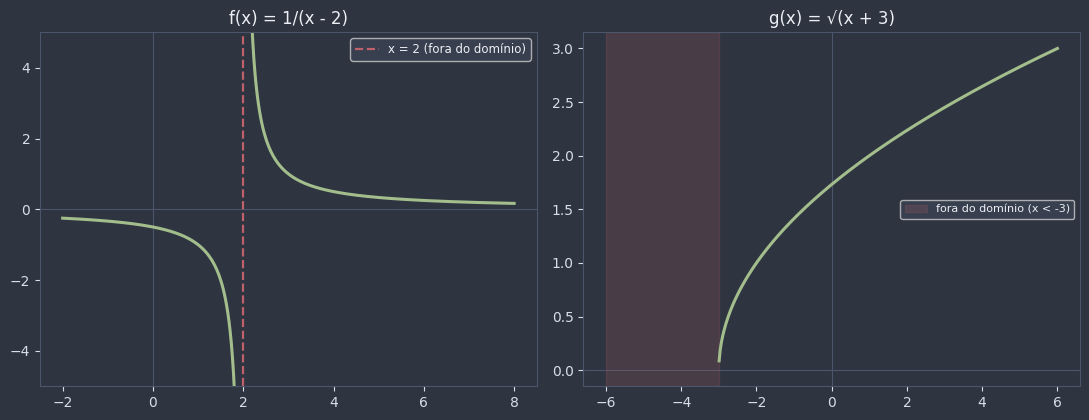

In [6]:
xs_f = np.linspace(-2, 8, 400)
xs_f_fora = xs_f[np.isclose(xs_f, 2, atol=0.02)]
xs_g = np.linspace(-6, 6, 400)
xs_g_fora = xs_g[xs_g < -3]
xs_g_dentro = xs_g[xs_g >= -3]

fig, (eixo_f, eixo_g) = plt.subplots(1, 2, figsize=(11, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)

for eixo in (eixo_f, eixo_g):
    eixo.set_facecolor(NORD_FUNDO)
    eixo.axhline(0, color=NORD_LINHA, linewidth=0.8, zorder=1)
    eixo.axvline(0, color=NORD_LINHA, linewidth=0.8, zorder=1)
    eixo.tick_params(colors=NORD_TEXTO_SEC)
    for spine in eixo.spines.values():
        spine.set_color(NORD_LINHA)

# f(x) = 1/(x-2): x=2 fica fora do domínio (assintota vertical)
xs_f_esq = xs_f[xs_f < 2]
xs_f_dir = xs_f[xs_f > 2]
eixo_f.plot(xs_f_esq, 1 / (xs_f_esq - 2), color=COR_DESTAQUE, linewidth=2.2)
eixo_f.plot(xs_f_dir, 1 / (xs_f_dir - 2), color=COR_DESTAQUE, linewidth=2.2)
eixo_f.axvline(2, color=COR_ALERTA, linewidth=1.6, linestyle="--", label="x = 2 (fora do domínio)")
eixo_f.set_ylim(-5, 5)
eixo_f.set_title("f(x) = 1/(x - 2)", color=NORD_TEXTO)
eixo_f.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8.5)

# g(x) = sqrt(x+3): x < -3 fica fora do domínio
eixo_g.axvspan(xs_g.min(), -3, color=COR_ALERTA, alpha=0.18, label="fora do domínio (x < -3)")
eixo_g.plot(xs_g_dentro, np.sqrt(xs_g_dentro + 3), color=COR_DESTAQUE, linewidth=2.2)
eixo_g.set_title("g(x) = √(x + 3)", color=NORD_TEXTO)
eixo_g.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8)

plt.tight_layout()
plt.show()

**Perguntas de checagem:**
1. Por que x = 2 não pode estar no domínio de f(x) = 1/(x - 2)?
2. Duas inequações equivalentes têm sempre o mesmo conjunto-solução?

## Gráfico de uma função no plano cartesiano

- Para representar f no plano cartesiano, marcamos cada par (x, f(x)) como um ponto. O conjunto de todos esses pontos, para todo x do domínio, é o **gráfico** de f.
- Isso fecha o ciclo das **múltiplas representações**: a mesma função pode ser vista pela fórmula (algébrica), pela tabela de valores (numérica) e pelo gráfico (geométrica) — as três descrevem exatamente a mesma coisa.

Use o slider para percorrer valores de x sobre o gráfico de h(x) = 0.5x² - 2x - 1 e ver o ponto (x, h(x)) em destaque.

In [ ]:
def h(x):
    return 0.5 * x**2 - 2 * x - 1


xs_h = np.linspace(-3, 7, 400)


def explorar_grafico(x: float) -> None:
    y = h(x)
    fig, ax = plt.subplots(figsize=(6, 4.3))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.plot(xs_h, h(xs_h), color=COR_DESTAQUE, linewidth=2.2, zorder=1)
    ax.scatter([x], [y], s=110, color=COR_PONTO, zorder=3)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8, zorder=0)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8, zorder=0)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.set_title(f"h({x:g}) = {y:g}  ->  ponto ({x:g}, {y:g})", color=NORD_TEXTO)
    plt.show()

    print(f"Par (x, h(x)) = ({x:g}, {y:g})")


widgets.interact(
    explorar_grafico,
    x=widgets.FloatSlider(value=1.0, min=-3, max=7, step=0.25, description="x:"),
)

interactive(children=(FloatSlider(value=1.0, description='x:', max=7.0, min=-3.0, step=0.25), Output()), _dom_…

<function __main__.explorar_grafico(x: float) -> None>

**Pergunta de checagem:**
1. O que representa, no gráfico, o valor de f(x) para um x escolhido?

## Teste da reta vertical

- 📌 **Definição formal:** uma curva no plano representa o gráfico de uma função de x se, e somente se, **toda reta vertical cruza a curva em no máximo um ponto**.
- Essa é exatamente a condição de **unicidade** do Bloco 2 (cada entrada tem no máximo uma saída), agora em versão gráfica: se uma reta vertical x = k cruzasse a curva duas vezes, a entrada k teria duas saídas diferentes — violando a definição de função.

Mova o slider para deslizar uma reta vertical x = k sobre dois gráficos: uma parábola "em pé" (y = x², função de x) e uma circunferência (não é função de x).

In [ ]:
def contar_intersecoes_parabola(k: float) -> list[tuple[float, float]]:
    return [(k, k**2)]


def contar_intersecoes_circulo(k: float, raio: float = 4.0) -> list[tuple[float, float]]:
    if abs(k) > raio:
        return []
    if np.isclose(abs(k), raio):
        return [(k, 0.0)]
    y = np.sqrt(raio**2 - k**2)
    return [(k, y), (k, -y)]


xs_parabola = np.linspace(-4.5, 4.5, 300)
theta = np.linspace(0, 2 * np.pi, 300)
raio_circulo = 4.0
xs_circulo = raio_circulo * np.cos(theta)
ys_circulo = raio_circulo * np.sin(theta)


def explorar_reta_vertical(k: float) -> None:
    pontos_parabola = contar_intersecoes_parabola(k)
    pontos_circulo = contar_intersecoes_circulo(k, raio_circulo)

    fig, (eixo_p, eixo_c) = plt.subplots(1, 2, figsize=(11, 4.6))
    fig.patch.set_facecolor(NORD_FUNDO)

    for eixo, curva_x, curva_y, pontos, titulo in [
        (eixo_p, xs_parabola, xs_parabola**2, pontos_parabola, "y = x² (é função)"),
        (eixo_c, xs_circulo, ys_circulo, pontos_circulo, "x² + y² = 16 (não é função)"),
    ]:
        eixo.set_facecolor(NORD_FUNDO)
        eixo.plot(curva_x, curva_y, color=COR_DESTAQUE, linewidth=2.2, zorder=1)
        eixo.axvline(k, color=COR_PONTO, linewidth=1.6, linestyle="--", zorder=2)
        if pontos:
            px, py = zip(*pontos)
            eixo.scatter(px, py, s=110, color=COR_ALERTA, zorder=3)
        eixo.axhline(0, color=NORD_LINHA, linewidth=0.7, zorder=0)
        eixo.axvline(0, color=NORD_LINHA, linewidth=0.7, zorder=0)
        eixo.set_xlim(-6, 6)
        eixo.set_ylim(-6, 6)
        eixo.set_aspect("equal")
        eixo.tick_params(colors=NORD_TEXTO_SEC)
        for spine in eixo.spines.values():
            spine.set_color(NORD_LINHA)
        eixo.set_title(
            f"{titulo}\nx = {k:g}: {len(pontos)} interseção(ões)",
            color=NORD_TEXTO, fontsize=10,
        )

    plt.tight_layout()
    plt.show()


widgets.interact(
    explorar_reta_vertical,
    k=widgets.FloatSlider(value=0.0, min=-6, max=6, step=0.25, description="x = k:"),
)

interactive(children=(FloatSlider(value=0.0, description='x = k:', max=6.0, min=-6.0, step=0.25), Output()), _…

<function __main__.explorar_reta_vertical(k: float) -> None>

🕵️ **Curiosidade histórica:** o plano cartesiano leva o nome de René Descartes, que no século XVII, na obra *La Géométrie* (1637), teve a ideia de descrever curvas geométricas por meio de equações algébricas. Foi essa fusão entre álgebra e geometria que tornou possível, séculos depois, formalizar testes puramente visuais — como o da reta vertical — em termos precisos de entrada e saída.

**Pergunta de checagem:**
1. Por que um círculo completo não representa uma função de x?

## Funções iguais

- 📌 **Definição formal:** duas funções f e g são **iguais** quando têm o **mesmo domínio**, o **mesmo contradomínio** e **f(x) = g(x) para todo x do domínio**.
- Duas leis de formação com "cara" bem diferente podem, depois de simplificadas, ser a mesma fórmula — mas isso **não basta**: se o domínio for diferente, as funções são diferentes.
- ⚠️ **Erro comum:** achar que "mesma fórmula simplificada" garante funções iguais, ignorando o domínio. f(x) = (x² - 1)/(x - 1) simplifica para x + 1, mas f **não está definida em x = 1** (denominador zero) — enquanto g(x) = x + 1 está definida em todo x.

In [9]:
import sympy as sp

x = sp.symbols("x")

f_expr = (x**2 - 1) / (x - 1)
g_expr = x + 1

f_simplificada = sp.simplify(f_expr)
formulas_equivalentes = sp.simplify(f_simplificada - g_expr) == 0

dominio_f = sp.calculus.util.continuous_domain(f_expr, x, sp.S.Reals)
dominio_g = sp.calculus.util.continuous_domain(g_expr, x, sp.S.Reals)

print(f"f(x) = (x²-1)/(x-1), simplificada: {f_simplificada}")
print(f"g(x) = {g_expr}")
print(f"Fórmulas equivalentes após simplificar? {formulas_equivalentes}")
print(f"Domínio de f: {dominio_f}")
print(f"Domínio de g: {dominio_g}")
print(f"f e g são a mesma função? {dominio_f == dominio_g}")

f(x) = (x²-1)/(x-1), simplificada: x + 1
g(x) = x + 1
Fórmulas equivalentes após simplificar? True
Domínio de f: Union(Interval.open(-oo, 1), Interval.open(1, oo))
Domínio de g: Reals
f e g são a mesma função? False


**Pergunta de checagem:**
1. f(x) = (x² - 1)/(x - 1) e g(x) = x + 1 são a mesma função? Por quê?

## Zeros (raízes) de uma função

- 📌 **Definição formal:** um **zero** (ou raiz) de uma função f é um valor de x para o qual f(x) = 0. Graficamente, é onde a curva **cruza ou toca** o eixo x.
- 📎 **Conexão:** os zeros de uma função vão ser retomados com força nos notebooks de Função de 1º e 2º Grau, para o "estudo do sinal" — saber onde f(x) é positiva, negativa ou zero.

Mova os sliders a, b, c da função f(x) = ax² + bx + c e veja, ao vivo, onde o gráfico cruza o eixo x.

In [ ]:
def zeros_quadratica(a: float, b: float, c: float) -> list[float]:
    '''Calcula os zeros reais de a*x^2 + b*x + c usando a fórmula de Bhaskara.'''
    if np.isclose(a, 0):
        return [] if np.isclose(b, 0) else [-c / b]
    discriminante = b**2 - 4 * a * c
    if discriminante < 0:
        return []
    if np.isclose(discriminante, 0):
        return [-b / (2 * a)]
    raiz_delta = np.sqrt(discriminante)
    return [(-b - raiz_delta) / (2 * a), (-b + raiz_delta) / (2 * a)]


def explorar_zeros(a: float, b: float, c: float) -> None:
    zeros = zeros_quadratica(a, b, c)
    xs = np.linspace(-8, 8, 400)
    ys = a * xs**2 + b * xs + c

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)
    ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=2.2, zorder=1)
    if zeros:
        ax.scatter(zeros, [0] * len(zeros), s=130, marker="X", color=COR_ALERTA, zorder=3)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8, zorder=0)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8, zorder=0)
    ax.set_ylim(-10, 10)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    zeros_texto = ", ".join(f"{z:g}" for z in zeros) if zeros else "nenhum zero real"
    ax.set_title(f"f(x) = {a:g}x² + {b:g}x + {c:g}\nzeros: {zeros_texto}", color=NORD_TEXTO, fontsize=10.5)
    plt.show()

    print(f"Zeros de f: {zeros}")


widgets.interact(
    explorar_zeros,
    a=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.25, description="a:"),
    b=widgets.FloatSlider(value=0.0, min=-6, max=6, step=0.5, description="b:"),
    c=widgets.FloatSlider(value=-4.0, min=-10, max=10, step=0.5, description="c:"),
)

interactive(children=(FloatSlider(value=1.0, description='a:', max=3.0, min=-3.0, step=0.25), FloatSlider(valu…

<function __main__.explorar_zeros(a: float, b: float, c: float) -> None>

**Pergunta de checagem:**
1. Uma função pode não ter nenhum zero? Dê um exemplo.

## Resumo

- **Função:** relação f de A em B onde todo elemento de A tem exatamente um correspondente em B (existência + unicidade).
- **Notação:** f: A → B; f é a função, f(x) é o valor dela em x.
- **Domínio, contradomínio, imagem:** domínio = conjunto de partida; contradomínio = conjunto de chegada; imagem = subconjunto do contradomínio efetivamente atingido. Im(f) ⊆ contradomínio, nem sempre igual.
- **Domínio de validade:** denominador ≠ 0; radicando ≥ 0 (índice par).
- **Inequações:** solução, conjunto-solução, inequações equivalentes (cuidado: inverter o sinal ao multiplicar/dividir por número negativo).
- **Teste da reta vertical:** toda reta vertical cruza o gráfico de uma função em no máximo um ponto.
- **Funções iguais:** mesmo domínio + mesmo contradomínio + mesma lei em todo o domínio.
- **Zero de uma função:** valor de x onde f(x) = 0 — onde o gráfico cruza (ou toca) o eixo x.

## Exercícios

**Básico**
1. Dadas algumas relações em diagrama de flechas, identificar quais são funções.
2. Calcular f(2), f(-1) e f(0) para uma função dada por fórmula simples.

**Intermediário**
1. Determinar o domínio de validade de f(x) = 1/(x-3) e de g(x) = √(2x-4).
2. Resolver uma inequação simples e escrever o conjunto-solução em notação de intervalo.

**Desafio**
1. Dadas duas funções com fórmulas diferentes, decidir (com justificativa, incluindo domínio) se são iguais.
2. Dado o gráfico de uma função definida por partes, identificar domínio, imagem e zeros.

### Básico

In [ ]:
# Exercício Básico 1: para cada relação de A_ex em B_ex abaixo, diga se é função
A_ex = {1, 2, 3, 4}
B_ex = {10, 20, 30}

relacao_1 = [(1, 10), (2, 10), (3, 20), (4, 30)]
relacao_2 = [(1, 10), (2, 20), (3, 30)]
relacao_3 = [(1, 10), (1, 20), (2, 10), (3, 20), (4, 30)]

eh_funcao_1 = ...  # eh_funcao(A_ex, relacao_1)
eh_funcao_2 = ...  # eh_funcao(A_ex, relacao_2)
eh_funcao_3 = ...  # eh_funcao(A_ex, relacao_3)

print(eh_funcao_1, eh_funcao_2, eh_funcao_3)

In [ ]:
# Verificação
assert eh_funcao_1 == eh_funcao(A_ex, relacao_1), (
    "Tente de novo, revise o passo 1: use eh_funcao(A_ex, relacao_1)."
)
assert eh_funcao_1 is True, (
    "Confira: todo elemento de A_ex (1,2,3,4) aparece em exatamente uma flecha."
)
assert eh_funcao_2 is False, (
    "Tente de novo: relacao_2 não cobre o elemento 4 de A_ex (falta existência)."
)
assert eh_funcao_3 is False, (
    "Tente de novo: relacao_3 tem duas flechas saindo do elemento 1 (falta unicidade)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: calcule f(2), f(-1) e f(0) para f(x) = 3x^2 - x + 1
def f_ex(x):
    return 3 * x**2 - x + 1


f_de_2 = ...
f_de_menos1 = ...
f_de_0 = ...

print(f_de_2, f_de_menos1, f_de_0)

In [ ]:
# Verificação
assert f_de_2 == f_ex(2), "Tente de novo, revise o passo 2: calcule f_ex(2)."
assert f_de_menos1 == f_ex(-1), "Tente de novo, revise o passo 2: calcule f_ex(-1)."
assert f_de_0 == f_ex(0), "Tente de novo, revise o passo 2: calcule f_ex(0)."
assert (f_de_2, f_de_menos1, f_de_0) == (11, 5, 1), (
    "Confira as contas: f_ex(2)=11, f_ex(-1)=5, f_ex(0)=1."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 1: determine o dominio de validade de f_int e g_int
# usando sympy (sp e x ja foram importados no Bloco 8)
f_int_expr = 1 / (x - 3)
g_int_expr = sp.sqrt(2 * x - 4)

dominio_f_int = ...  # dica: sp.calculus.util.continuous_domain(f_int_expr, x, sp.S.Reals)
dominio_g_int = ...  # dica: mesma função, aplicada a g_int_expr

print(dominio_f_int, dominio_g_int)

In [ ]:
# Verificação
esperado_f = sp.calculus.util.continuous_domain(f_int_expr, x, sp.S.Reals)
esperado_g = sp.calculus.util.continuous_domain(g_int_expr, x, sp.S.Reals)
assert dominio_f_int == esperado_f, (
    "Tente de novo, revise o passo 1: o denominador x-3 não pode ser zero."
)
assert dominio_g_int == esperado_g, (
    "Tente de novo, revise o passo 1: o radicando 2x-4 precisa ser >= 0."
)
assert dominio_f_int == sp.S.Reals - sp.FiniteSet(3), (
    "Confira: x-3 != 0 -> x != 3, entao o domínio e R - {3}."
)
assert dominio_g_int == sp.Interval(2, sp.oo), (
    "Confira: 2x-4 >= 0 -> x >= 2, entao o domínio e [2, +infinito)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 2: resolva a inequação 3x - 5 > 2x + 1 e escreva o
# conjunto-solução como um sp.Interval
conjunto_solucao_ex = ...  # dica: isole x passo a passo, depois monte o Interval

print(conjunto_solucao_ex)

In [ ]:
# Verificação
esperado = sp.solveset(3 * x - 5 > 2 * x + 1, x, domain=sp.S.Reals)
assert conjunto_solucao_ex == esperado, (
    "Tente de novo: some/subtraia dos dois lados ate isolar x. "
    "3x - 5 > 2x + 1  ->  x > 6."
)
assert conjunto_solucao_ex == sp.Interval.open(6, sp.oo), (
    "Confira: o conjunto-solução e o intervalo aberto (6, +infinito)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 1: f_des(x) = (x^2 - 4)/(x - 2) e g_des(x) = x + 2 são a
# mesma função? Justifique comparando o domínio das duas (use sympy)
f_des_expr = (x**2 - 4) / (x - 2)
g_des_expr = x + 2

funcoes_iguais_ex = ...  # True ou False

print(funcoes_iguais_ex)

In [ ]:
# Verificação
dominio_f_des = sp.calculus.util.continuous_domain(f_des_expr, x, sp.S.Reals)
dominio_g_des = sp.calculus.util.continuous_domain(g_des_expr, x, sp.S.Reals)
assert funcoes_iguais_ex == (dominio_f_des == dominio_g_des), (
    "Tente de novo: compare o domínio de f_des_expr com o de g_des_expr."
)
assert funcoes_iguais_ex is False, (
    "Confira: f_des_expr simplifica para x+2, mas fica indefinida em x=2 "
    "(denominador zero) -> o domínio de f_des e R-{2}, diferente do domínio de g_des (R)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 2: dado o gráfico de uma função definida por partes,
# identifique domínio, imagem e zeros
def f_partes(valor):
    return valor + 2 if valor < 0 else -valor + 2


xs_partes_esq = np.linspace(-6, 0, 200)
xs_partes_dir = np.linspace(0, 6, 200)
fig, ax = plt.subplots(figsize=(6, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)
ax.plot(xs_partes_esq, xs_partes_esq + 2, color=COR_DESTAQUE, linewidth=2.2)
ax.plot(xs_partes_dir, -xs_partes_dir + 2, color=COR_DESTAQUE, linewidth=2.2)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.tick_params(colors=NORD_TEXTO_SEC)
for spine in ax.spines.values():
    spine.set_color(NORD_LINHA)
ax.set_title("f(x) = x+2 se x<0, ou -x+2 se x>=0", color=NORD_TEXTO, fontsize=10)
plt.show()

dominio_partes_ex = ...  # sp.Interval(...)
imagem_partes_ex = ...  # sp.Interval(...)
zeros_partes_ex = ...  # um set com os zeros, ex: {a, b}

print(dominio_partes_ex, imagem_partes_ex, zeros_partes_ex)

In [ ]:
# Verificação
assert dominio_partes_ex == sp.Interval(-sp.oo, sp.oo), (
    "Tente de novo: as duas partes juntas cobrem todo x<0 e todo x>=0 -> domínio = R."
)
assert imagem_partes_ex == sp.Interval(-sp.oo, 2), (
    "Tente de novo: o pico e f(0)=2 (máximo); os dois ramos caem sem limite -> "
    "imagem = (-infinito, 2]."
)
assert zeros_partes_ex == {-2, 2}, (
    "Tente de novo: resolva x+2=0 (válido para x<0) e -x+2=0 (válido para x>=0)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0104a_relacoes.ipynb`](0104a_relacoes.ipynb) (relação entre conjuntos, pares ordenados)
- [00_fundamentos_e_python/](../00_fundamentos_e_python/) (variáveis, funções em Python)

**Isso será usado em:**
- [`0106a_classificacao_e_operacoes_com_funcoes.ipynb`](0106a_classificacao_e_operacoes_com_funcoes.ipynb) (crescimento, paridade, injetora/sobrejetora/bijetora, operações e inversa — tudo parte do que foi definido aqui)
- Função de 1º Grau e Função de 2º Grau (domínio, gráfico, zeros e inequações reaparecem o tempo todo)
- Praticamente todo o restante do curso, sempre que uma grandeza depender de outra